In [48]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from os import getcwd, listdir
import missingno as msno
import re
import plotly.express as px
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor
import joblib
from scipy import sparse
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
getcwd()

'C:\\Users\\AmiranBehine.com'

In [52]:
# Portable repository paths are configured above; no local chdir needed.
warnings.filterwarnings("ignore")

In [ ]:
df_main=pd.read_csv(DATA_RAW / "divar_real_estate_ads.csv")
df=df_main.copy()

In [51]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.0f}'.format)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 60 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   cat2_slug                   1000000 non-null  object 
 1   cat3_slug                   999999 non-null   object 
 2   city_slug                   999998 non-null   object 
 3   neighborhood_slug           437139 non-null   object 
 4   created_at_month            1000000 non-null  object 
 5   user_type                   288882 non-null   object 
 6   description                 1000000 non-null  object 
 7   title                       999946 non-null   object 
 8   rent_mode                   352994 non-null   object 
 9   rent_value                  351322 non-null   float64
 10  rent_to_single              19 non-null       object 
 11  rent_type                   103961 non-null   object 
 12  price_mode                  573606 non-null   object 
 13

In [8]:
df.describe()

,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,regular_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,3.513220e+05,5.683460e+05,3.520950e+05,3.520850e+05,7.240900e+04,3.512480e+05,7.240900e+04,1.863960e+05,9.803940e+05,29870.000000,1.024100e+04,1.806800e+04,1.046300e+04,1.355100e+04,655608.000000,655608.000000,339699.000000
mean,4.102299e+10,1.736537e+10,4.872084e+10,4.872222e+10,8.557025e+09,4.103164e+10,1.619934e+07,4.165480e+03,4.440648e+03,6.557650,1.209785e+10,1.389016e+11,2.355548e+10,3.156551e+10,34.982108,51.629743,465.149147
std,3.807534e+12,5.878739e+11,4.341346e+12,4.341407e+12,2.064576e+12,3.807935e+12,5.217890e+07,1.218927e+05,1.367118e+05,7.698655,1.103482e+12,7.042335e+12,1.542049e+12,2.434942e+12,2.379169,3.160920,125.896250
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,23.626478,40.162369,0.000000
25%,1.111110e+05,1.400000e+09,1.000000e+08,1.000000e+08,2.000000e+08,1.111110e+05,1.000000e+06,1.100000e+02,7.500000e+01,3.000000,5.000000e+04,4.000000e+05,6.000000e+05,5.500000e+05,34.553551,50.677175,500.000000
50%,5.000000e+06,2.840000e+09,2.500000e+08,2.500000e+08,4.000000e+08,5.000000e+06,6.000000e+06,1.950000e+02,1.030000e+02,4.000000,1.000000e+05,8.000000e+05,1.200000e+06,1.100000e+06,35.723312,51.345791,500.000000
75%,1.200000e+07,5.900000e+09,5.000000e+08,5.000000e+08,8.500000e+08,1.200000e+07,1.500000e+07,2.800000e+02,1.650000e+02,7.000000,2.000000e+05,1.600000e+06,2.500000e+06,2.500000e+06,36.307013,51.805291,500.000000
max,1.000000e+15,1.000000e+14,1.000000e+15,1.000000e+15,5.555556e+14,1.000000e+15,3.000000e+09,1.000000e+07,1.000000e+07,50.000000,1.111111e+14,5.006007e+14,1.111111e+14,2.002503e+14,40.358055,74.511620,500.000000


## بررسی کیفیت داده
1. مقادیر ناموجود در هر یک از ستون‌ها را بررسی و ستون‌ها و ردیف‌هایی که مقادیر موجود بیشتری دارند را مشخص کنید.

In [13]:
nan_cols = (df.isna().mean() * 100).sort_values(ascending=False)

nan_rows = (df.isna().mean(axis=1) * 100).sort_values(ascending=False)

print(nan_cols.head(30))
print(nan_rows.head(30))

rent_to_single                99.9981
cost_per_extra_person         98.9759
rent_price_on_special_days    98.9537
rent_price_at_weekends        98.6449
rent_price_on_regular_days    98.1932
extra_person_capacity         97.5991
property_type                 97.2943
has_sauna                     97.1521
has_jacuzzi                   97.1272
has_pool                      97.0610
regular_person_capacity       97.0130
has_barbecue                  96.8802
has_security_guard            96.8688
has_gas                       96.6570
has_water                     96.6556
has_electricity               96.6555
has_business_deed             96.5321
transformed_credit            92.7591
transformed_rent              92.7591
rent_type                     89.6039
land_size                     81.3604
deed_type                     74.6542
user_type                     71.1118
unit_per_floor                69.7717
total_floors_count            69.5648
building_direction            67.6077
location_rad

## Duplicate
2. آیا ردیف‌های تکراری در داده وجود دارد؟

DataFrame.duplicated(keep = ['first', 'last'])

DataFrame.drop_duplicates(inplace, keep = ['first','last'])

Dataframe.reset_index(inplace, drop)

In [220]:
dup_series = df.duplicated().sum() 
dup_series

np.int64(0)

3.آیا چیزی از جنس تناقض و ناسازگاری مقداری در داده مشاهده می‌کنید؟ به عنوان نمونه به این صورت که در یک سلول مقدار غیرمرتبط و از نظر منطقی نادرست نوشته شده باشد. مثلا در ستونی که قرار است متن بیاید عدد آمده باشد یا در ستونی که قرار است عدد یک یا دو رقمی بیاید، مقدار متفاوتی ثبت شده است.

In [7]:
#check categorical columns
exclude_cols = ['title', 'description','created_at_month']

for col in df.columns:
    if df[col].dtype == 'object' and col not in exclude_cols:  # categorical column
        print(f"Column: {col}")
        print(f"number of notnull values: {df[col].notna().sum()}")
        print(f"number of NAN values: {df[col].isna().sum()}")
        print(df[col].value_counts(dropna=False))  # include NaN counts
        print("-" * 70)


Column: cat2_slug
number of notnull values: 1000000
number of NAN values: 0
cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64
----------------------------------------------------------------------
Column: cat3_slug
number of notnull values: 999999
number of NAN values: 1
cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
indust

## inconsistencies </br>
It is seen data inconsistencies in **floor** , **total_floors_count** , **has_balcony** , **extra_person_capacity** columns.</br>
in **floor** there are float and str and negetive number and 30+</br>
in **total_floors_count** there are float and str and **unselect** and 30+ </br>
in **extra_person_capacity** there are float and str and 30+</br>
in **has_balcony** there are 'true', 'false', **'unselect'**, True, False</br>


In [88]:
df = df.replace(
    to_replace=['NA', 'None', '', ' ', 'nan', 'NaN', 'N/A', 'NULL',pd.NA, None],
    value=np.nan
)

#first of all,we replace all unselect value in whole data frame with nan(except title and description):
cols_to_clean = df.columns.difference(['title', 'description'])

df[cols_to_clean] = df[cols_to_clean].replace(
    r'(?i)unselect', 
    np.nan, 
    regex=True
)
print(df.has_balcony.unique())

#has_balcony: replace 'true' and 'false' string with boolean True and False respectively:
df['has_balcony'] = (
    df['has_balcony']
    .str.lower()                     # make 'TRUE', 'True', etc. consistent
    .replace({'true': True, 'false': False})
)


bool_cols = [
    'has_gas', 'has_water', 'has_elevator',
    'has_warehouse', 'has_parking', 'is_rebuilt', 
    'has_electricity', 'has_security_guard', 'has_barbecue',
    'has_pool', 'has_jacuzzi', 'has_sauna'
]
for col in bool_cols:
    if col not in df.columns:
        print(f"Skipping missing column: {col}")
        continue

    # map known patterns → boolean
    df[col] = df[col].map(
        {
            'True': True, 'False': False,
            '1': True, '0': False,
            1: True, 0: False,
            True: True, False: False
        }
    )
    # convert to boolean dtype
    df[col] = df[col].astype('boolean')
    #df[col] = df[col].fillna(False)

    print(f"Column cleaned: {col}")


[nan 'true' 'false' True False]
Column cleaned: has_gas
Column cleaned: has_water
Column cleaned: has_elevator
Column cleaned: has_warehouse
Column cleaned: has_parking
Column cleaned: is_rebuilt
Column cleaned: has_electricity
Column cleaned: has_security_guard
Column cleaned: has_barbecue
Column cleaned: has_pool
Column cleaned: has_jacuzzi
Column cleaned: has_sauna


In [89]:
# floor
df.loc[df['floor'] == '30+', 'floor'] = 31
df['floor'] = pd.to_numeric(df['floor'], errors='coerce').astype('Int64')

# total_floors_count
df.loc[df['total_floors_count'] == '30+', 'total_floors_count'] = 31
df['total_floors_count'] = pd.to_numeric(df['total_floors_count'], errors='coerce').astype('Int64')

# rooms_count
mapping = {
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر': 5,
    'بدون اتاق': 0,
    np.nan: np.nan  # keep NaN as NaN
}
df['rooms_count'] = df['rooms_count'].map(mapping)
df['rooms_count'] = pd.to_numeric(df['rooms_count'], errors='coerce').astype('Int64')

#unit_per_floor
df['unit_per_floor'] = df['unit_per_floor'].replace('more_than_8', 9)# Replace 'more_than_8' with 9
df['unit_per_floor'] = pd.to_numeric(df['unit_per_floor'], errors='coerce')# Convert the rest of the column to numeric (strings → numbers)

# Construction year
def persian_to_english(s):
    if pd.isna(s):
        return s
    persian_digits = '۰۱۲۳۴۵۶۷۸۹'
    english_digits = '0123456789'
    trans_table = str.maketrans(persian_digits, english_digits)
    return str(s).translate(trans_table)

df.loc[df['construction_year'] == 'قبل از ۱۳۷۰', 'construction_year'] = '۱۳۷۰'
df['construction_year'] = df['construction_year'].apply(persian_to_english)
df['construction_year'] = pd.to_numeric(df['construction_year'], errors='coerce').astype('Int64')

# age from construction_year if present
df['age'] = np.where(df['construction_year'].notna(), 1404 - df['construction_year'], np.nan)  # adjust year
df['age'].isna().sum()
df.drop(columns=['construction_year'],inplace=True)

#extra_person_capacity
df.loc[df['extra_person_capacity'] == '30+', 'extra_person_capacity'] = 30
df['extra_person_capacity'] = pd.to_numeric(df['extra_person_capacity'], errors='coerce').astype('Int64')

## check outliers

In [81]:
df.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'price_mode',
       'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform',
       'transformable_price', 'transformable_credit', 'transformed_credit',
       'transformable_rent', 'transformed_rent', 'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'is_rebuilt', 'has_warm_water_provider',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'building_direction', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person_capacity',
       'cost_per_extra_person', 'rent_price_on_regular_days',
       'rent_price_on_special_days', 'rent_price_at_weekends',
       'location_la

In [90]:

# remove from data 1111111..., 22222222...., 333333333... ,4444...,5555..,6666...,777777...,8888...,999999999... patterns thar are fake numbers
cols = ['rent_value', 'price_value', 'credit_value', 'transformable_credit','transformed_credit','transformable_rent', 'transformed_rent',
       'rent_price_on_regular_days','rent_price_on_special_days','rent_price_at_weekends','cost_per_extra_person']

pattern_anywhere = r'(1{5,}|2{5,}|3{5,}|4{5,}|5{5,}|6{5,}|7{5,}|8{5,}|9{5,})'

for col in cols:
    df[col + '_str'] = df[col].astype('Int64').astype(str)
    df[col + '_str'] = df[col + '_str'].str.replace(r'\.0$', '', regex=True)
    mask = df[col + '_str'].str.contains(pattern_anywhere, na=False)
    df.loc[mask, col] = np.nan
    

df.drop(columns=[c + '_str' for c in cols if (c + '_str') in df.columns],
        inplace=True)

    
df[[
    'rent_value',
    'credit_value',
    'price_value',
    'transformed_credit',
    'transformable_credit',
    'transformed_rent',
    'transformable_rent','rent_price_on_regular_days','rent_price_on_special_days','rent_price_at_weekends','cost_per_extra_person'
]].describe()

,rent_value,credit_value,price_value,transformed_credit,transformable_credit,transformed_rent,transformable_rent,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,cost_per_extra_person
count,"341,873","345,134","554,529","72,379","345,124","72,279","341,799","17,743","10,207","13,273","10,048"
mean,"1,081,044,270","9,116,643,639","14,047,848,073","884,786,975","9,116,898,745","16,223,315","1,081,277,589","103,104,925,625","1,160,582,662","15,277,319,944","40,151,583"
std,"318,830,991,707","1,503,133,773,837","450,794,911,398","2,666,853,737","1,503,155,549,713","52,221,980","318,865,503,241","6,806,600,038,238","81,303,572,345","1,738,176,619,818","2,825,759,882"
min,0,0,0,0,0,0,0,0,0,0,0
25%,"400,000","100,000,000","1,500,000,000","200,000,000","100,000,000","1,000,000","400,000","400,000","600,000","580,000","50,000"
50%,"5,000,000","250,000,000","2,900,000,000","400,000,000","250,000,000","6,000,000","5,000,000","800,000","1,200,000","1,100,000","100,000"
75%,"12,000,000","500,000,000","5,950,000,000","850,000,000","500,000,000","15,000,000","12,000,000","1,600,000","2,500,000","2,500,000","200,000"
max,"120,000,000,050,040","500,000,000,000,000","90,000,000,000,000","350,000,000,000","500,000,000,000,000","3,000,000,000","120,000,000,050,040","500,600,700,800,900","5,806,807,801,150","200,250,300,400,450","200,300,400,500"


In [92]:
def has_at_least_6_distinct_digits(x):
    if pd.isna(x):
        return False
    s = str(int(float(x)))  # convert to string safely
    distinct_digits = set([d for d in s if d.isdigit()])
    return len(distinct_digits) >= 6

cols = [
    'rent_value','credit_value','price_value',
    'transformed_credit','transformable_credit',
    'transformed_rent','transformable_rent',
    'rent_price_on_regular_days','rent_price_on_special_days',
    'rent_price_at_weekends','cost_per_extra_person'
]

for c in cols:
    mask = df[c].apply(has_at_least_6_distinct_digits)
    df.loc[mask, c] = np.nan

In [93]:
# we need only upper bound because lower bound must be 0
def cap_values(df, column):
    """
    Caps a numeric column:
        lower bound = 0
        upper bound = 99th percentile
    Replaces values below / above bounds with the bounds.
    """
    upper = df[column].quantile(0.9)
    
    df[column] = df[column].clip(lower=0, upper=upper)
    return df

columns_to_cap = [
    'rent_value', 'credit_value', 'price_value',
    'transformed_credit', 'transformed_rent','rent_price_on_regular_days','rent_price_on_special_days','rent_price_at_weekends','cost_per_extra_person'
]

for col in columns_to_cap:
    if col in df.columns:
        df = cap_values(df, col)

df[columns_to_cap].describe()

,rent_value,credit_value,price_value,transformed_credit,transformed_rent,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,cost_per_extra_person
count,"341,541","344,851","553,059","72,379","72,277","17,732","10,201","13,266","10,043"
mean,"8,563,099","357,618,377","4,239,973,347","609,307,817","9,639,745","1,058,798","1,611,963","1,544,684","131,238"
std,"9,710,699","315,477,309","3,711,219,895","501,773,938","10,494,485","848,628","1,315,541","1,241,857","103,459"
min,0,0,0,0,0,0,0,0,0
25%,"400,000","100,000,000","1,500,000,000","200,000,000","1,000,000","400,000","600,000","580,000","50,000"
50%,"5,000,000","250,000,000","2,900,000,000","400,000,000","6,000,000","800,000","1,200,000","1,100,000","100,000"
75%,"12,000,000","500,000,000","5,945,000,000","850,000,000","15,000,000","1,600,000","2,500,000","2,500,000","200,000"
max,"30,000,000","1,000,000,000","12,306,400,000","1,700,000,000","32,000,000","2,600,000","4,000,000","3,800,000","300,000"


In [26]:
# this is need for text proccessing
mask_title_len1 = df['title'].astype(str).str.len() == 1
mask_desc_len1  = df['description'].astype(str).str.len() == 1

# Rows where both title and description have length 1
mask_both_len1 = mask_title_len1 & mask_desc_len1

# View the problematic rows
df[mask_both_len1]


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
52251,residential-sell,apartment-sell,tehran,east-tehranpars,2024-08-01 00:00:00,NaN,پ,پ,NaN,NaN,NaN,NaN,مقطوع,"1,616",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300,NaN,NaN,1,3,<NA>,NaN,NaN,True,False,True,1403,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stone,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,36,52,NaN
393040,residential-rent,house-villa-rent,pool,NaN,2024-06-01 00:00:00,NaN,پ,پ,مقطوع,"1,500,000",NaN,NaN,NaN,NaN,مقطوع,"10,000,000",False,False,"10,000,000",NaN,"1,500,000",NaN,161,161,NaN,NaN,<NA>,1,<NA>,NaN,True,NaN,True,False,1387,False,True,NaN,True,True,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,36,51,NaN


# Missing Values

In [94]:
df['cat3_slug'] = df['cat3_slug'].fillna('office_rent')


In [95]:
# fill columns about floor with 1 or 0 in not apartments
# Define categories that should NOT be filled with 1
excluded_categories = [
    'apartment-sell', 'apartment-rent',
    'partnership', 'presell','plot-old'
]

# Create mask for rows where cat3_slug is NOT in excluded categories
mask = ~df['cat3_slug'].isin(excluded_categories)

# Fill NaN only in those rows, only for specific columns
df.loc[mask, ['floor', 'total_floors_count','unit_per_floor']] = (
    df.loc[mask, ['floor', 'total_floors_count','unit_per_floor']].fillna(1)
)
df.loc[(df['cat3_slug']=='plot-old'), ['floor', 'total_floors_count','unit_per_floor']] = (
    df.loc[mask, ['floor', 'total_floors_count','unit_per_floor']]
    .fillna(0)
)

In [96]:
#for rows that bothe of building_size and land_size are NAN, search the title and description and
# if there is 'meter' word in them,if also there is one of the keywords_land words and there isnt any of exclude_words,it must be 
# the land_size and the building_size must be zero,and else it is building size.
df_before = df.copy()
print(df[df['building_size'].isna() & df['land_size'].isna()].shape)

keywords_land = ['زمین', 'باغچه', 'چهاردیواری', 'باغ']
exclude_words = ['بنا', 'زیربنا', 'ویو', 'تهاتر', 'تعویض']  # example exclude words

def extract_number(text):
    """Extracts the last number before/after 'متر' in the text."""
    match = re.search(r'(\d+)\s*متر', text)
    return int(match.group(1)) if match else np.nan

def impute_sizes(row):
    if pd.isna(row['building_size']) and pd.isna(row['land_size']):
        # Check both title and description
        for col in ['title', 'description']:
            text = row[col]
            if isinstance(text, str) and 'متر' in text:
                num = extract_number(text)
                if not np.isnan(num):
                    if any(k in text for k in keywords_land) and not any(e in text for e in exclude_words):
                        row['land_size'] = num
                    else:
                        row['building_size'] = num
                    return row
    return row

df[['building_size', 'land_size']] = df.apply(impute_sizes, axis=1)[['building_size', 'land_size']]

print(df[df['building_size'].isna() & df['land_size'].isna()].shape)


(19606, 60)
(5985, 60)


In [97]:
# Define the property types
apartment_types = ['apartment-sell', 'apartment-rent', 'suite-apartment']

# Fill NaN land_size with 0 for these rows
df.loc[df['cat3_slug'].isin(apartment_types), 'land_size'] =df.loc[df['cat3_slug'].isin(apartment_types), 'land_size'].fillna(0)


In [98]:
df_before=df.copy()
# Apply your existing mask
words_include = ['زمین', 'باغچه', 'چهاردیواری', 'باغ']
words_exclude = ['بنا', 'زیربنا','ویو','تهاتر','تعویض']

mask = (
    (df['building_size'].notna()) &
    (df['building_size'] > 0) &
    (df['land_size'].isna()) &
    (df['cat3_slug'] == 'plot-old') &
    (
        df['description'].fillna('').str.contains('|'.join(words_include), na=False) |
        df['title'].fillna('').str.contains('|'.join(words_include), na=False)
    ) &
    ~(
        df['description'].fillna('').str.contains('|'.join(words_exclude), na=False) |
        df['title'].fillna('').str.contains('|'.join(words_exclude), na=False)
    )
)

# Swap: Move building_size → land_size
df.loc[mask, 'land_size'] = df.loc[mask, 'building_size']

# Set building_size = 0 for those rows
df.loc[mask, 'building_size'] = 0


#df_filtered = df.loc[mask, ['cat3_slug','title', 'description', 'building_size', 'land_size','price_value']]
##df_filtered.head(10)


In [99]:
luxury_cols = [
    'has_pool', 'has_jacuzzi', 'has_sauna',
    'has_security_guard', 'has_barbecue'
]

necessary_cols = [
    'has_gas', 'has_water', 'has_electricity'
]

# Replace missing values with False (optional)
df[luxury_cols] = df[luxury_cols].fillna(False)
df[necessary_cols] = df[necessary_cols].fillna(False)

# Create new aggregated columns
df['extra_facility'] = df[luxury_cols].sum(axis=1)
df['necessary_facility'] = df[necessary_cols].sum(axis=1)

df.drop(columns=['has_pool','has_jacuzzi','has_sauna','has_security_guard','has_barbecue','has_gas', 'has_water', 'has_electricity'], inplace=True)
#dff=df[(df['extra_facility']>0) | (df['necessary_facility']>0)]
#dff[['extra_facility','necessary_facility']]

In [100]:
print(df.shape)
df = df[(df['price_value'] != 1)&(df['rent_value'] != 1)&(df['credit_value'] != 1)]
print(df.shape)

(1000000, 54)
(999545, 54)


In [101]:
#remove building_size and land_sizes that are NAN and 1 or both are 1 or both are nan
df = df[
    ~((df['building_size'] == 1) &
    (df['land_size'] == 1)) &
    ~(df['building_size'].isna() & (df['land_size'] == 1)) &
    ~((df['building_size'] == 1) & df['land_size'].isna()) &
    ~((df['building_size'].isna())  & (df['land_size'].isna()))
].copy()
df.shape

(993124, 54)

In [102]:
valid_types = (str)   # expected type
col = "city_slug"

# mask for rows that are NOT valid
mask_unusual = ~df[col].map(lambda x: isinstance(x, valid_types))

# view unusual rows
df_unusual = df[mask_unusual]
print(df_unusual[[col]])

# drop the unusual rows from the original DataFrame
df = df[~mask_unusual]
df.dropna(subset=["city_slug"],inplace=True)

# check
print(df[col].dtype)
print(df.shape)


       city_slug
292674       NaN
676502       NaN
object
(993122, 54)


In [103]:
#check inconsistency in neighborhood_slug

valid_types = (str)   # you can change this
col = "neighborhood_slug"
mask_unusual = ~df[col].map(lambda x: isinstance(x, valid_types))
df_unusual = df[mask_unusual].dropna()
print(df_unusual[[col]])     # only the problematic column
#print(df_unusual)            # full rows


Empty DataFrame
Columns: [neighborhood_slug]
Index: []


In [105]:
print(f"before:{df["user_type"].isna().mean() * 100}")
#my_df[my_df["user_type"].notna()]
def user_type_filling(row):
    if pd.isna(row["user_type"]):
        desc = str(row["description"])  # اگه خالی بود، خطا نده
        if "املاک" in desc or "گروه" in desc or "مهندس" in desc or "هلدینگ" in desc or "کد" in desc or "کارشناس" in desc or "مشاور" in desc:
            return "مشاور املاک"
        elif "مالک" in desc or "بدون واسطه" in desc:
            return "شخصی"
    return row["user_type"]
df["user_type"] = df.apply(user_type_filling, axis=1)
#my_df["user_type"] = df["user_type"]

print(f"after:{df["user_type"].isna().mean() * 100}")

before:47.04276010399528
after:47.04276010399528


In [26]:
df.user_type.unique()


array(['مشاور املاک', nan, 'شخصی'], dtype=object)

In [106]:
df2 = df[df['cat2_slug'] != 'real-estate-services']

In [107]:
# Rent categories
#choose relevalent columns for rent
rent_categories = [ 'residential-rent', 'commercial-rent']
rent_cols = [
    'cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type',  'credit_mode', 'credit_value', 
       'land_size', 'building_size',
       'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'age', 'is_rebuilt',
       'has_warm_water_provider',
        'necessary_facility','extra_facility', 
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'building_direction', 'floor_material', 'location_latitude', 'location_longitude',
   # 'has_pool','has_jacuzzi','has_sauna','has_security_guard','has_barbecue','has_gas', 'has_water', 'has_electricity'
]

df_rent = df2[df2['cat2_slug'].isin(rent_categories)][rent_cols]



In [108]:
#choose relevalent columns for sell
sell_cols = [
   'cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title',
       'price_mode',
       'price_value',
       'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'age', 'is_rebuilt',
       'has_warm_water_provider',
       'necessary_facility','extra_facility',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'building_direction', 'floor_material', 'property_type',       
       'location_latitude', 'location_longitude'
    #,'has_pool','has_jacuzzi',
    #'has_sauna','has_security_guard','has_barbecue','has_gas', 'has_water', 'has_electricity'
]

# Sell categories
sell_categories = [ 'residential-sell', 'commercial-sell']

df_sell = df2[df2['cat2_slug'].isin(sell_categories)][sell_cols]

In [111]:
# Temporary Rent categories
#choose relevalent columns for temporary rent
temp_rent_categories = ['temporary-rent']
temp_rent_cols = [
    'cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 
       'land_size', 'building_size',
        'rooms_count','has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'age', 'is_rebuilt',
        'necessary_facility','extra_facility', 
       'has_warm_water_provider', 
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'building_direction', 
       'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person_capacity',
       'cost_per_extra_person', 'rent_price_on_regular_days',
       'rent_price_on_special_days', 'rent_price_at_weekends',
       'location_latitude', 'location_longitude'#,'has_pool','has_jacuzzi','has_sauna','has_security_guard',
    #'has_barbecue','has_gas', 'has_water', 'has_electricity'
]

df_temp_rent = df2[df2['cat2_slug'].isin(temp_rent_categories)][temp_rent_cols]



In [112]:
print("Rent ads:", df_rent.shape)
print("Sell ads:", df_sell.shape)
print("temporary rent ads:", df_temp_rent.shape)

Rent ads: (352764, 36)
Sell ads: (596930, 35)
temporary rent ads: (29876, 34)


In [113]:
df_rent = df_rent[df_rent['rent_value'].notna() | df_rent['credit_value'].notna()]# remove rows that has not price
df_temp_rent = df_temp_rent[df_temp_rent['rent_price_on_regular_days'].notna() | df_temp_rent['rent_price_on_special_days'].notna() | df_temp_rent['rent_price_at_weekends'].notna()]
df_sell = df_sell[df_sell['price_value'].notna() ]
df_sell= df_sell[df_sell['price_mode'].ne('مجانی')]


In [33]:
s= df_sell[(df_sell['price_mode']=='توافقی')  ] 
s.shape

(0, 35)

In [115]:
df_temp_rent = df_temp_rent[df_temp_rent['rent_price_on_regular_days'].notna() | \
df_temp_rent['rent_price_on_special_days'].notna()\
| df_temp_rent['rent_price_at_weekends'].notna()]

#Drop columns with >70% NaN and Drop rows with >88% NaN
nan_percent_row = df_temp_rent.isna().mean(axis=1) * 100# Calculate NaN percentage per row
df_temp_rent=df_temp_rent[(nan_percent_row <= 92) ]# Keep rows with <= 95% NaN

nan_percent_col = df_temp_rent.isna().mean() * 100 # Calculate NaN percentage per column
df_temp_rent = df_temp_rent.loc[:, nan_percent_col <= 90] # Keep columns with <= 70% NaN
df_temp_rent.shape

(17951, 22)

In [116]:
df_sell = df_sell[df_sell['price_value'].notna() ]

#Drop columns with >70% NaN and Drop rows with >88% NaN
nan_percent_row = df_sell.isna().mean(axis=1) * 100# Calculate NaN percentage per row
df_sell=df_sell[(nan_percent_row <= 90) ]# Keep rows with <= 95% NaN

nan_percent_col = df_sell.isna().mean() * 100 # Calculate NaN percentage per column
df_sell = df_sell.loc[:, nan_percent_col <= 90] # Keep columns with <= 70% NaN
df_sell.shape

(549381, 33)

In [118]:
df_rent = df_rent[df_rent['rent_value'].notna() | df_rent['credit_value'].notna()]# remove rows that has not price

#Drop columns with >70% NaN and Drop rows with >88% NaN
nan_percent_row = df_rent.isna().mean(axis=1) * 100# Calculate NaN percentage per row
df_rent=df_rent[(nan_percent_row <= 90) ]# Keep rows with <= 95% NaN

nan_percent_col = df_rent.isna().mean() * 100 # Calculate NaN percentage per column
df_rent = df_rent.loc[:, nan_percent_col <= 90] # Keep columns with <= 70% NaN
df_rent.shape

(345764, 35)

# EDA

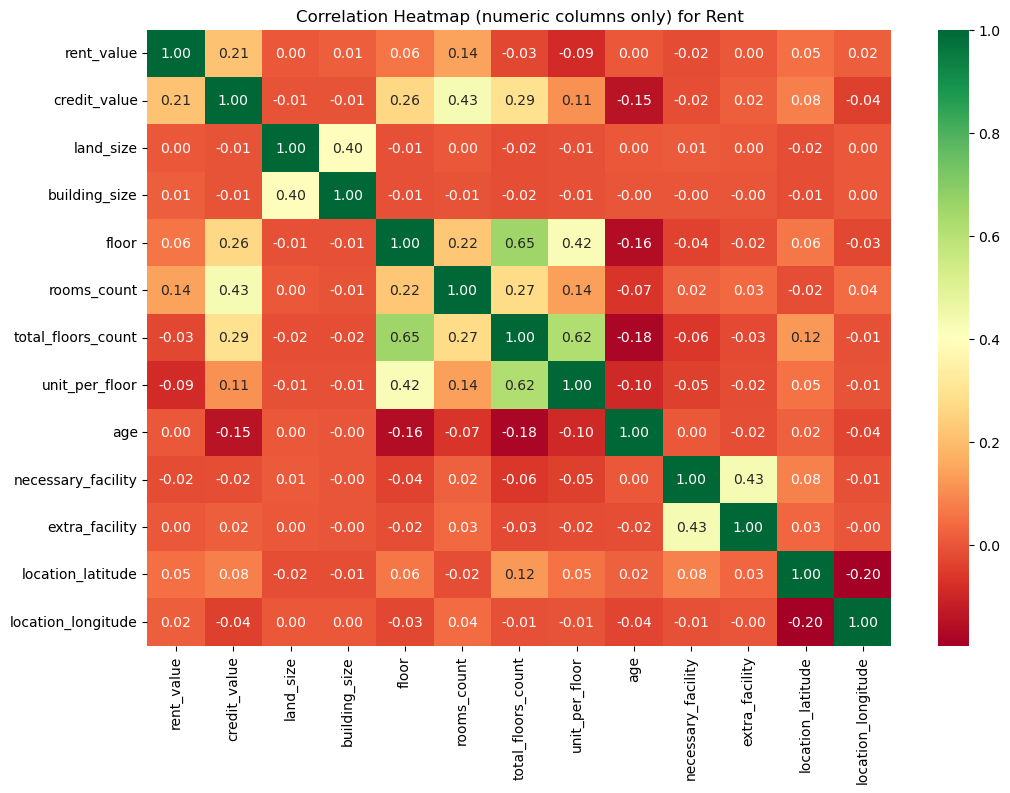

In [41]:
numeric_df = df_rent.select_dtypes(include=['int64', 'float64', 'float32', 'Int64', 'int32'])

corr_matrix = numeric_df.corr()


plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Correlation Heatmap (numeric columns only) for Rent" )
plt.show()


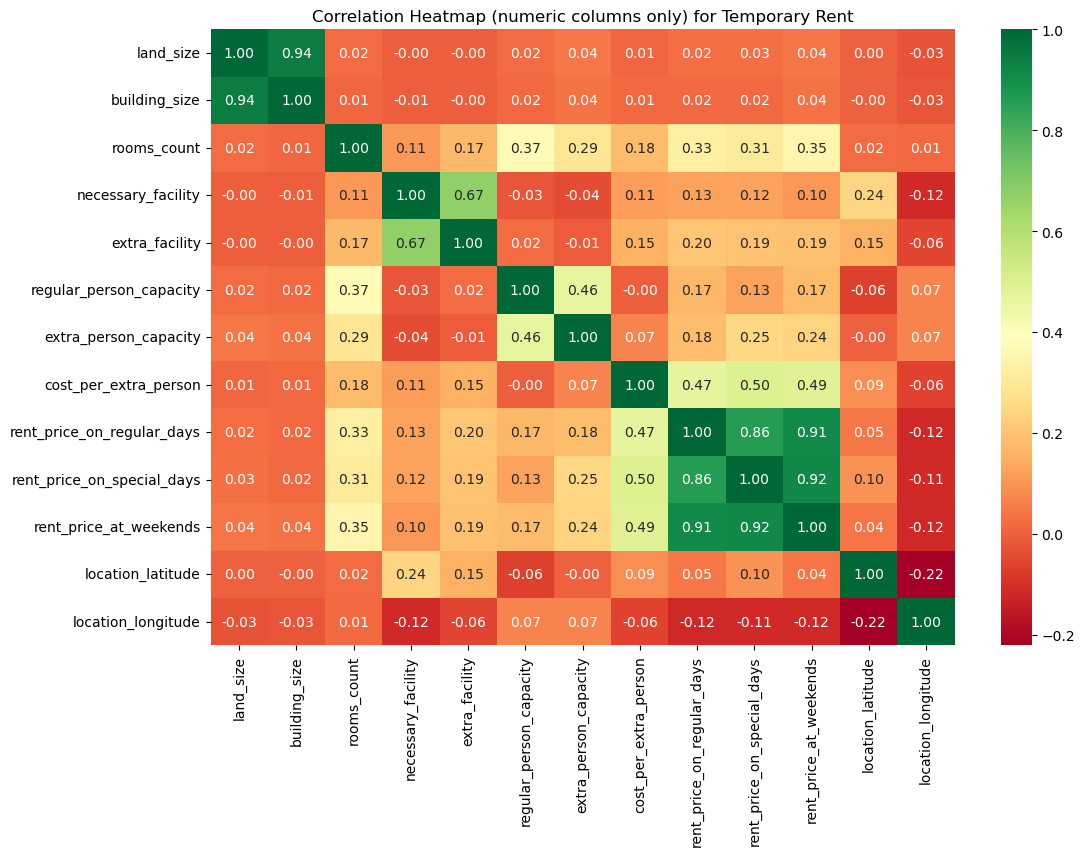

In [42]:
numeric_df = df_temp_rent.select_dtypes(include=['int64', 'float64', 'float32', 'Int64', 'int32'])

corr_matrix = numeric_df.corr()


plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Correlation Heatmap (numeric columns only) for Temporary Rent" )
plt.show()


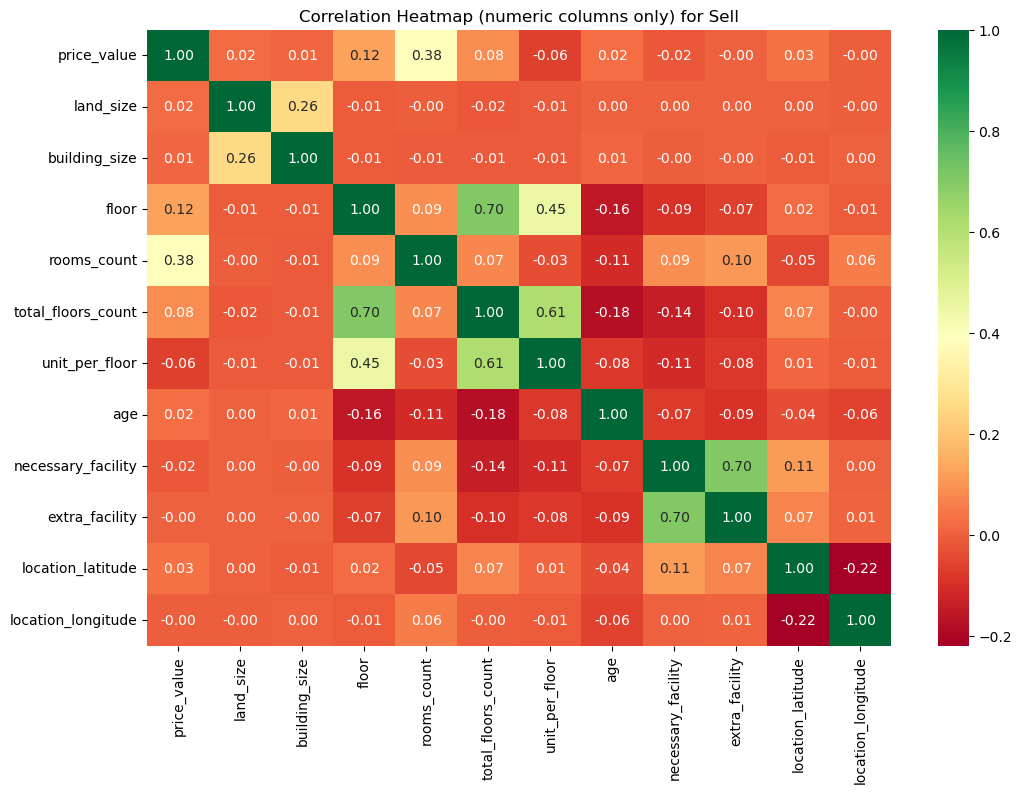

In [43]:
numeric_df = df_sell.select_dtypes(include=['int64', 'float64', 'float32', 'Int64', 'int32'])

corr_matrix = numeric_df.corr()


plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Correlation Heatmap (numeric columns only) for Sell" )
plt.show()


In [55]:
df_sell.groupby('cat2_slug')['cat2_slug'].agg('count')
df_sell.groupby('cat3_slug')['cat3_slug'].agg('count')

cat3_slug
apartment-sell                        298883
house-villa-sell                      116171
industry-agriculture-business-sell      8485
office-sell                             4326
plot-old                              106985
shop-sell                              17735
Name: cat3_slug, dtype: int64

In [27]:
df_temp_rent.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title',
       'building_size', 'rooms_count', 'necessary_facility', 'extra_facility',
       'property_type', 'regular_person_capacity', 'extra_person_capacity',
       'cost_per_extra_person', 'rent_price_on_regular_days',
       'rent_price_on_special_days', 'rent_price_at_weekends',
       'location_latitude', 'location_longitude'],
      dtype='object')

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# 🔹 Columns to impute
num_cols = ['age', 'rooms_count', 'building_size', 'floor', 
            'total_floors_count', 'unit_per_floor']

# 🔹 Categorical features to guide KNN similarity
cat_cols = ['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug']

# 🔹 Ensure columns exist
num_cols = [c for c in num_cols if c in df.columns]
cat_cols = [c for c in cat_cols if c in df.columns]

# 🔹 Create a working copy
df_knn = df.copy()

# 🔹 Encode categorical columns safely
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_knn[col] = df_knn[col].astype(str).fillna('Unknown')
    df_knn[col] = le.fit_transform(df_knn[col])
    encoders[col] = le  # Saving in case needed later

# 🔹 KNN works only on selected columns
knn_features = num_cols + cat_cols
data_for_knn = df_knn[knn_features]

# 🔹 Apply KNN imputer
imputer = KNNImputer(n_neighbors=5, weights='distance')
imputed_array = imputer.fit_transform(data_for_knn)

# 🔹 Convert imputed array back to DataFrame
imputed_df = pd.DataFrame(imputed_array, columns=knn_features, index=df_knn.index)

# 🔹 Replace only numerical columns in original df
for col in num_cols:
    df[col] = np.round(imputed_df[col]).astype('Int64')

print("\n🔍 Remaining NaN values after KNN:")
print(df[num_cols].isna().sum())

df[num_cols].describe()


array([[<Axes: title={'center': 'rent_value'}>,
        <Axes: title={'center': 'credit_value'}>,
        <Axes: title={'center': 'land_size'}>,
        <Axes: title={'center': 'building_size'}>],
       [<Axes: title={'center': 'floor'}>,
        <Axes: title={'center': 'rooms_count'}>,
        <Axes: title={'center': 'total_floors_count'}>,
        <Axes: title={'center': 'unit_per_floor'}>],
       [<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'necessary_facility'}>,
        <Axes: title={'center': 'extra_facility'}>,
        <Axes: title={'center': 'location_latitude'}>],
       [<Axes: title={'center': 'location_longitude'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

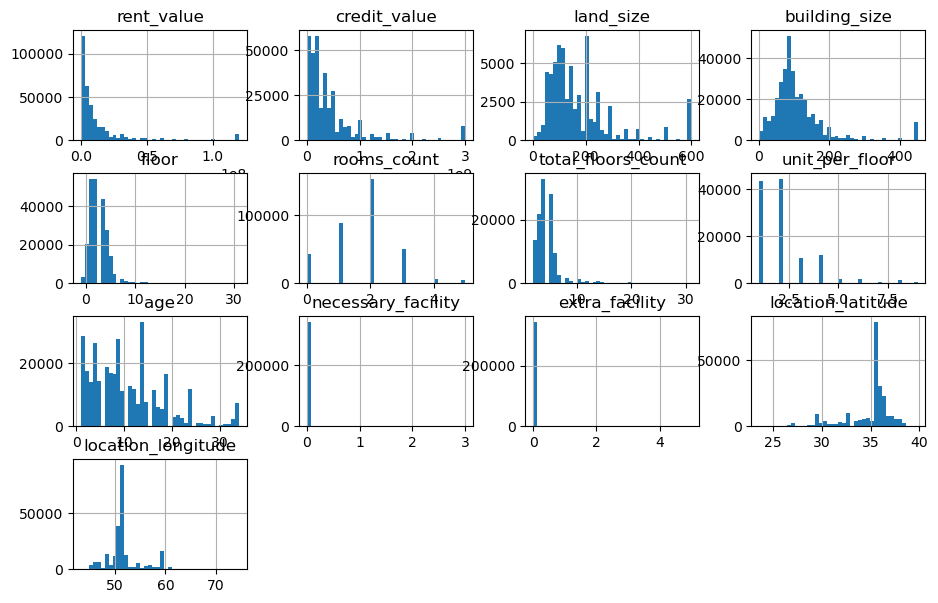

In [55]:
df_rent.hist(bins=40, figsize=(11,7))

array([[<Axes: title={'center': 'price_value'}>,
        <Axes: title={'center': 'land_size'}>,
        <Axes: title={'center': 'building_size'}>],
       [<Axes: title={'center': 'floor'}>,
        <Axes: title={'center': 'rooms_count'}>,
        <Axes: title={'center': 'total_floors_count'}>],
       [<Axes: title={'center': 'unit_per_floor'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'necessary_facility'}>],
       [<Axes: title={'center': 'extra_facility'}>,
        <Axes: title={'center': 'location_latitude'}>,
        <Axes: title={'center': 'location_longitude'}>]], dtype=object)

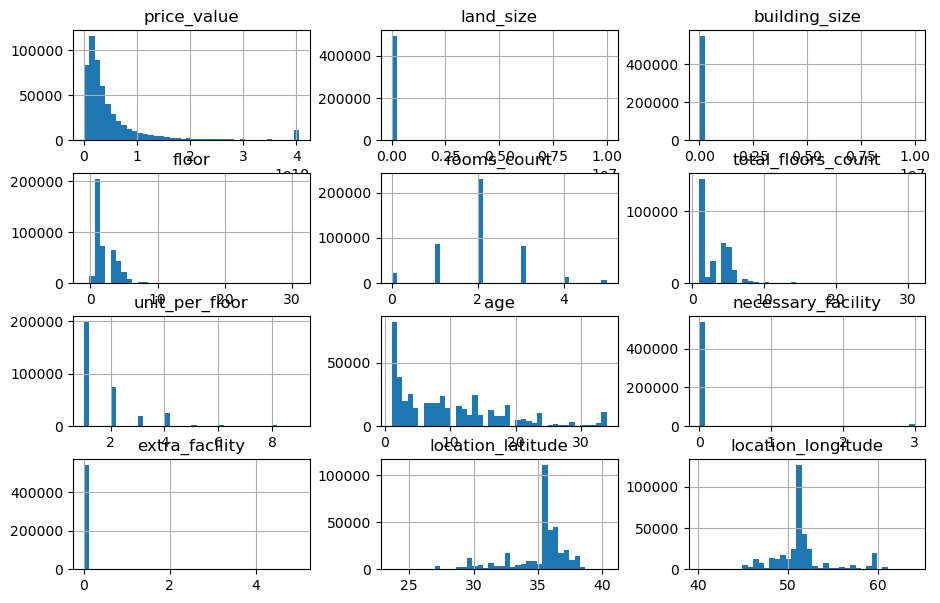

In [101]:
df_sell.hist(bins=40, figsize=(11,7))

array([[<Axes: title={'center': 'building_size'}>,
        <Axes: title={'center': 'rooms_count'}>,
        <Axes: title={'center': 'necessary_facility'}>],
       [<Axes: title={'center': 'extra_facility'}>,
        <Axes: title={'center': 'regular_person_capacity'}>,
        <Axes: title={'center': 'extra_person_capacity'}>],
       [<Axes: title={'center': 'cost_per_extra_person'}>,
        <Axes: title={'center': 'rent_price_on_regular_days'}>,
        <Axes: title={'center': 'rent_price_on_special_days'}>],
       [<Axes: title={'center': 'rent_price_at_weekends'}>,
        <Axes: title={'center': 'location_latitude'}>,
        <Axes: title={'center': 'location_longitude'}>]], dtype=object)

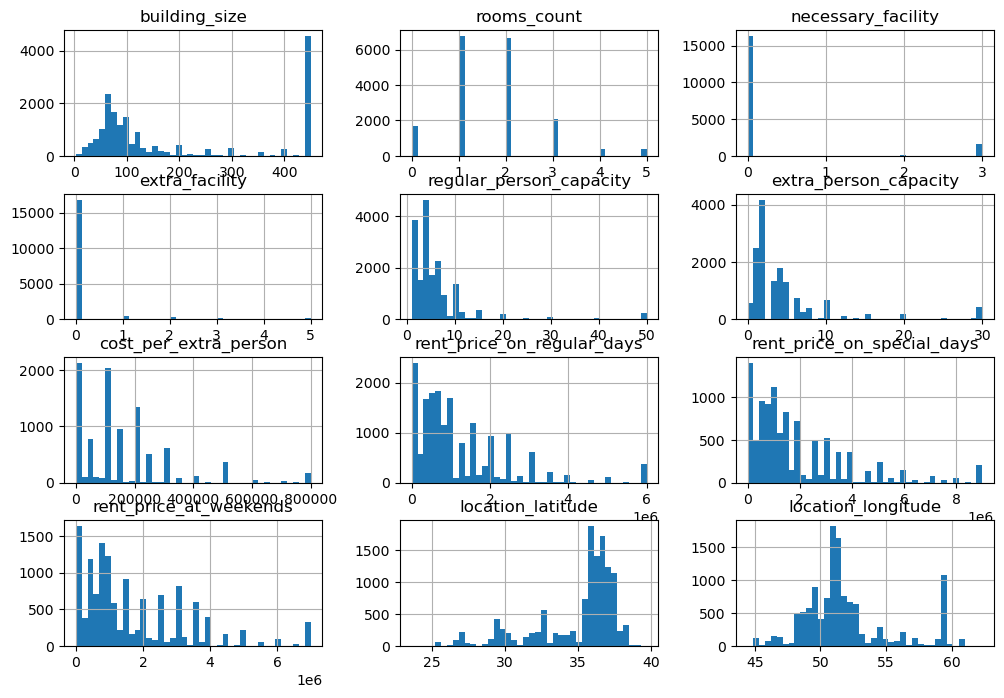

In [57]:
df_temp_rent.hist(bins=40, figsize=(12,8))

Top 15 numeric columns correlated with price_value:
['price_value', 'building_size', 'rooms_count', 'floor', 'total_floors_count', 'unit_per_floor', 'location_latitude', 'land_size', 'construction_year', 'location_longitude']


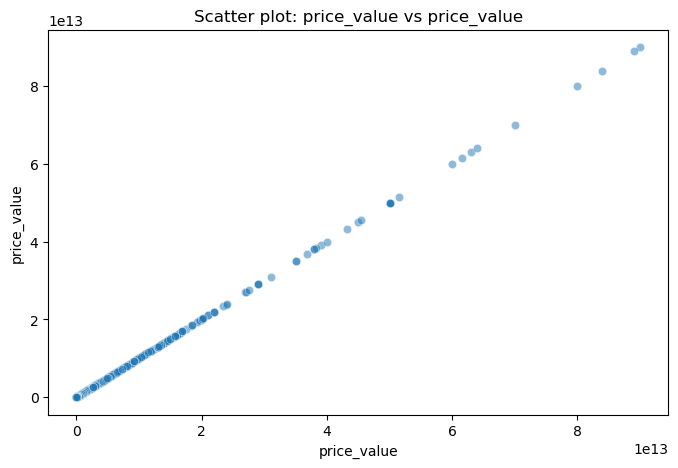

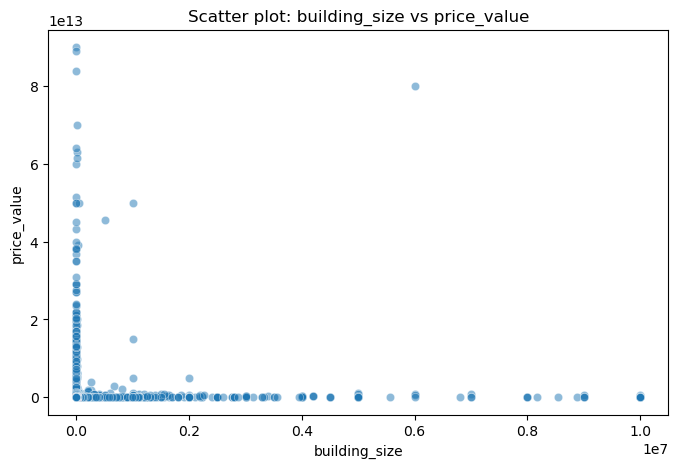

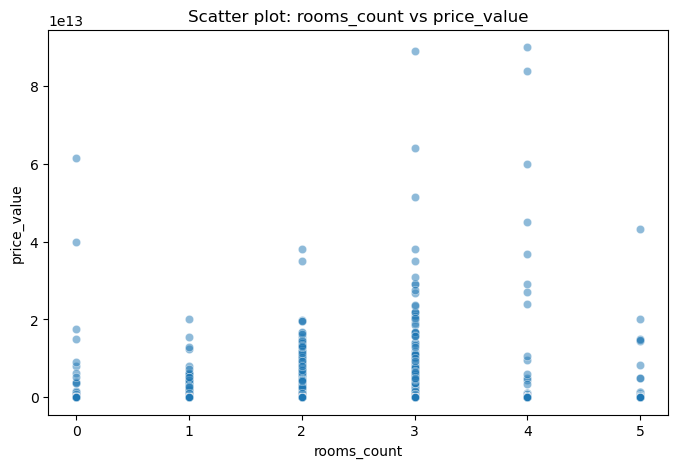

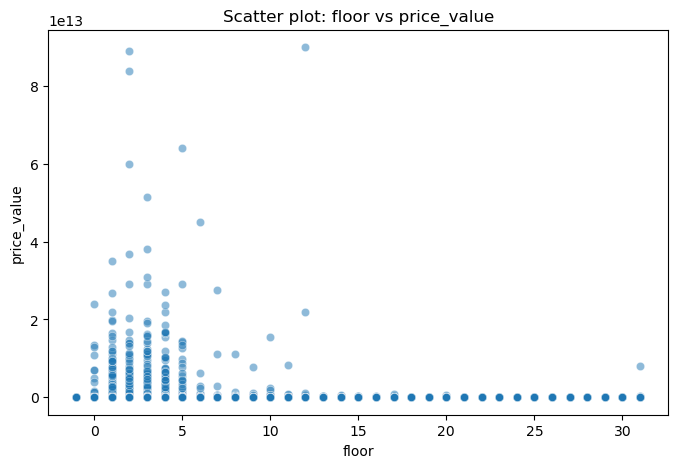

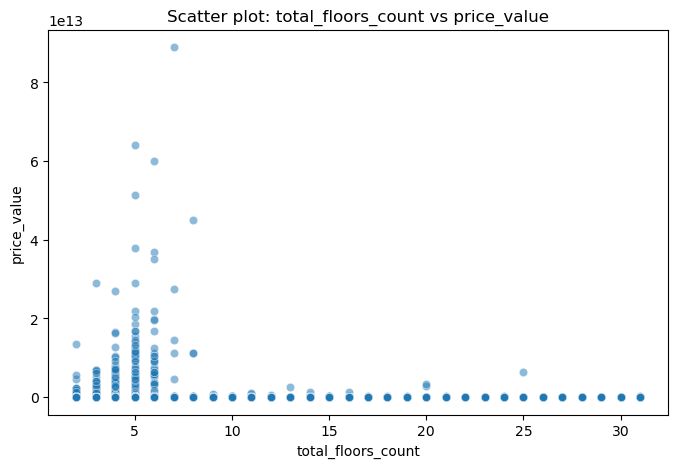

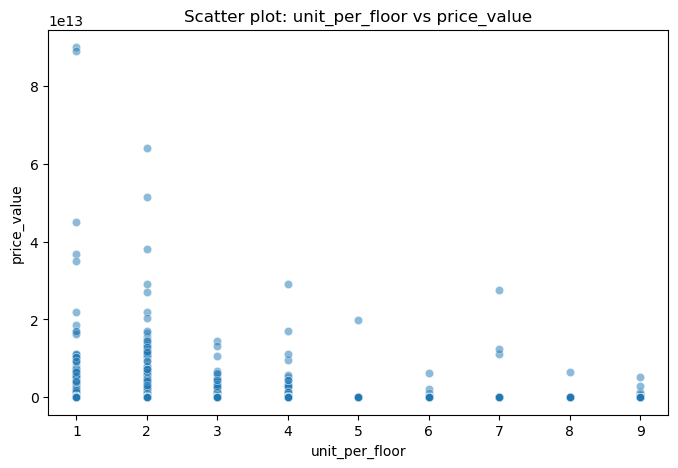

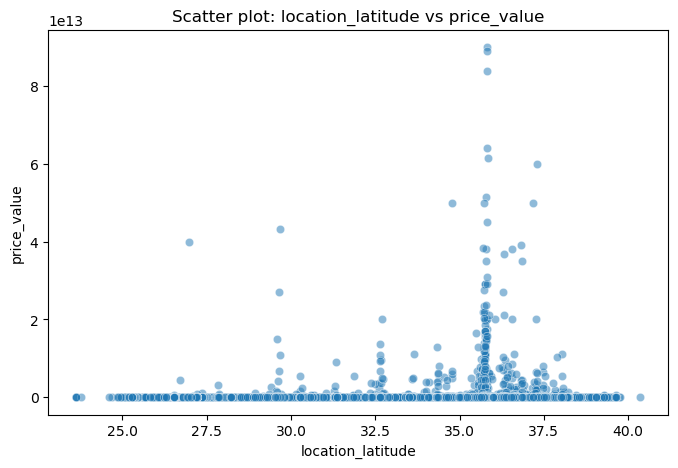

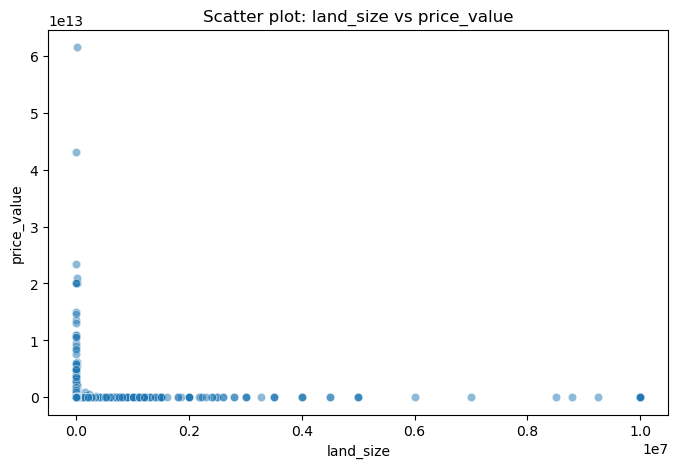

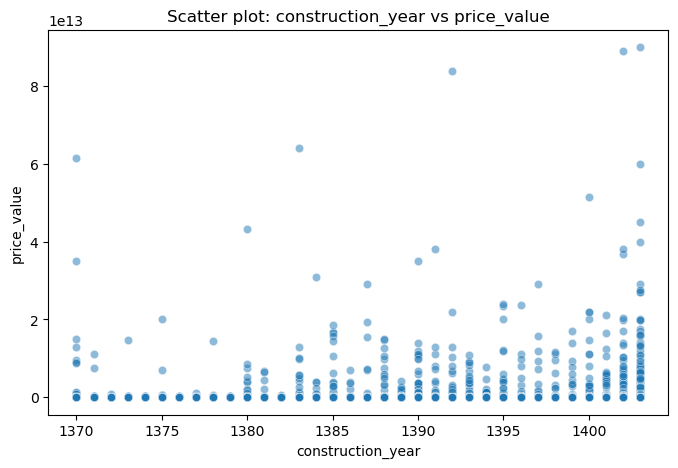

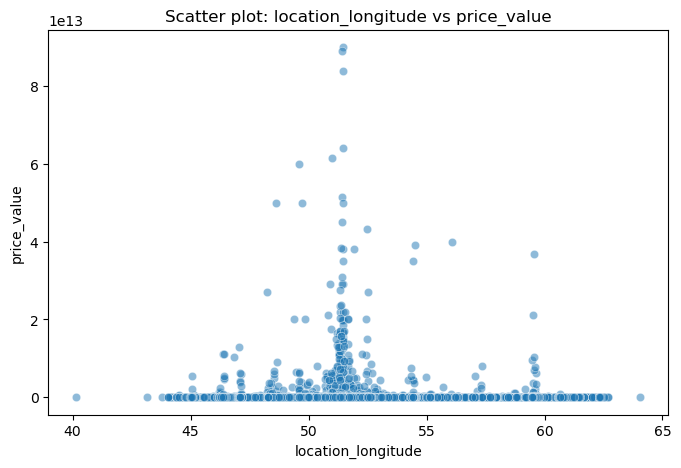

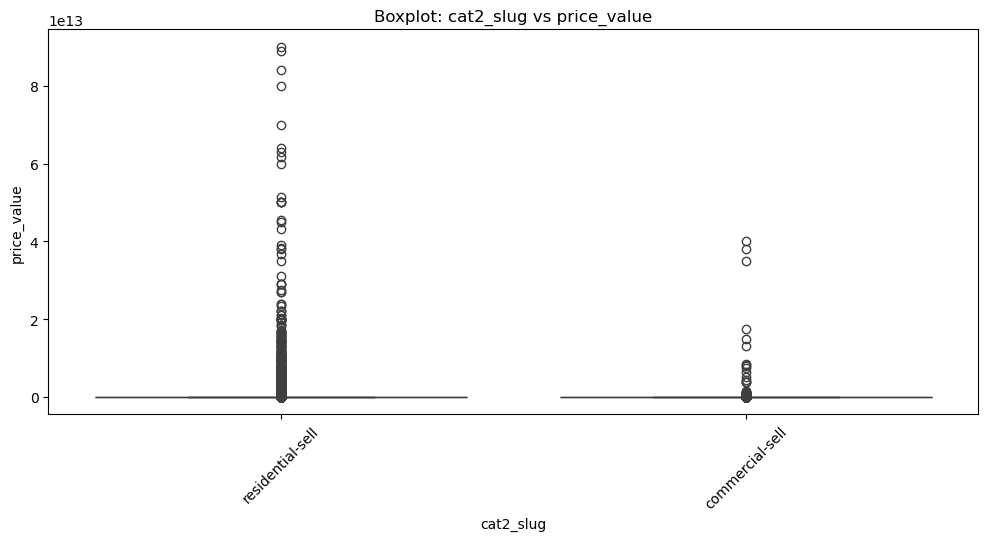

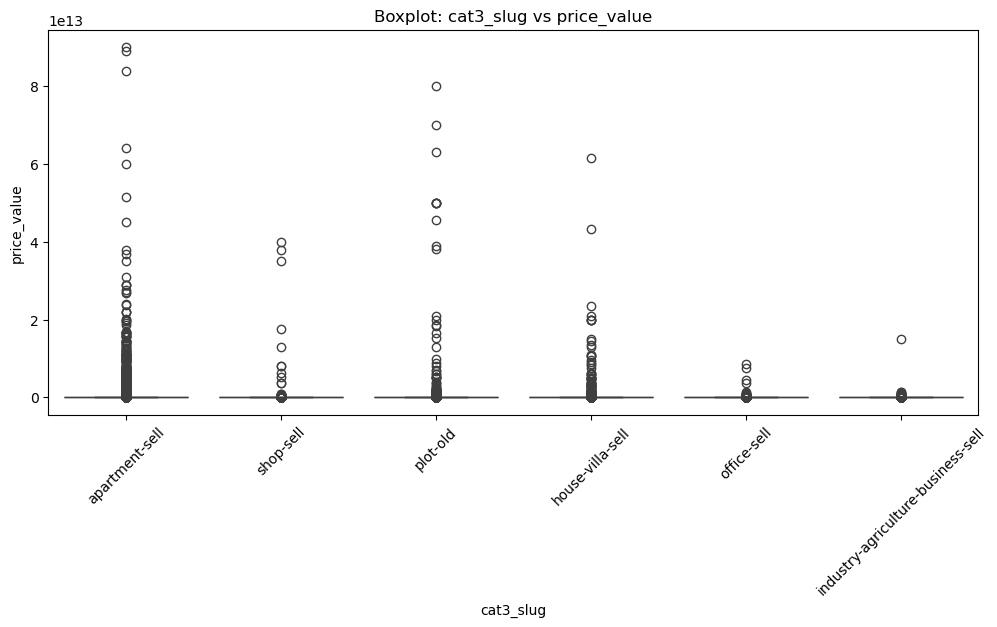

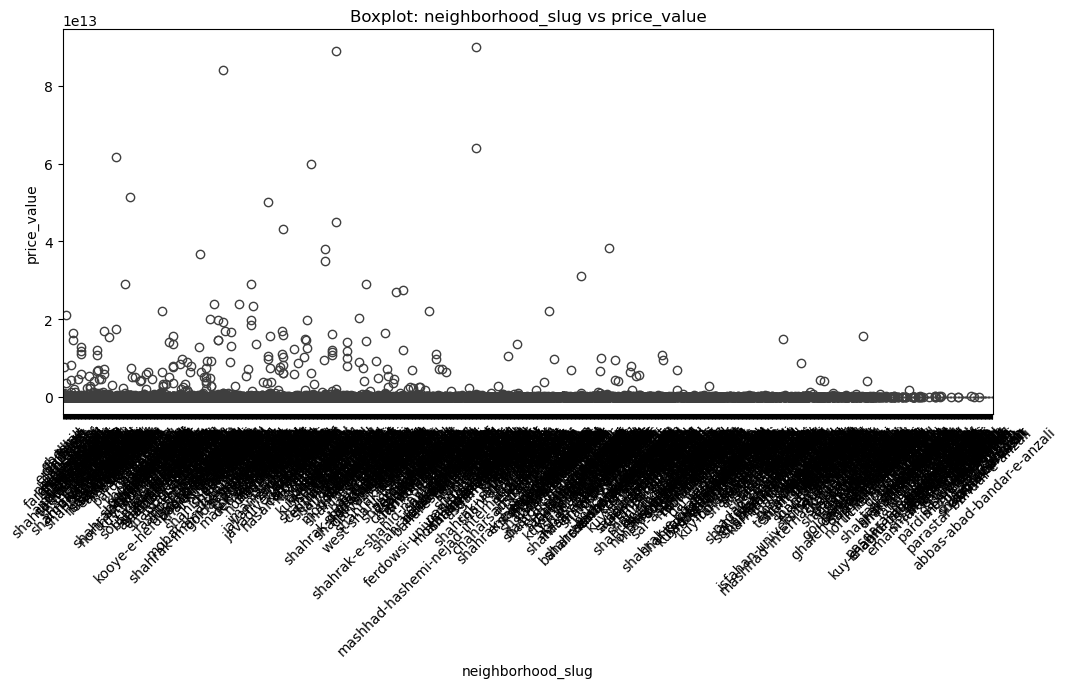

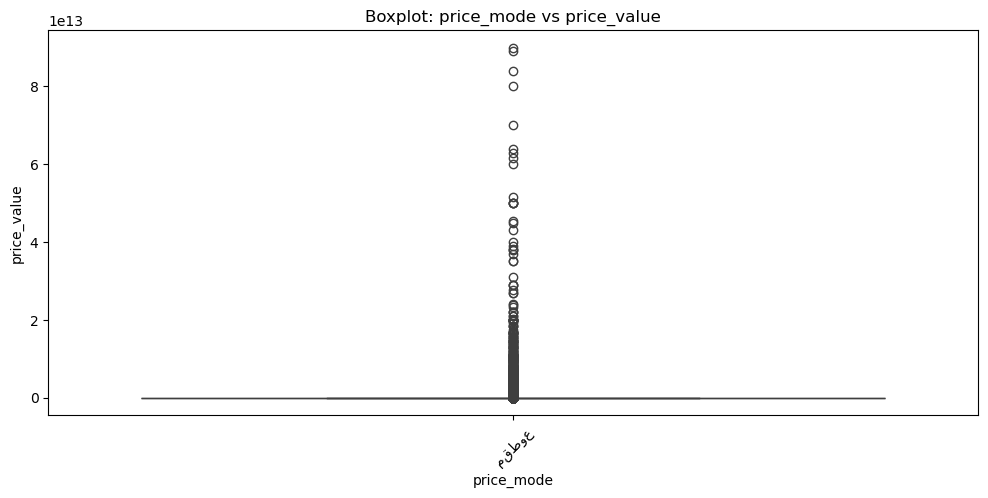

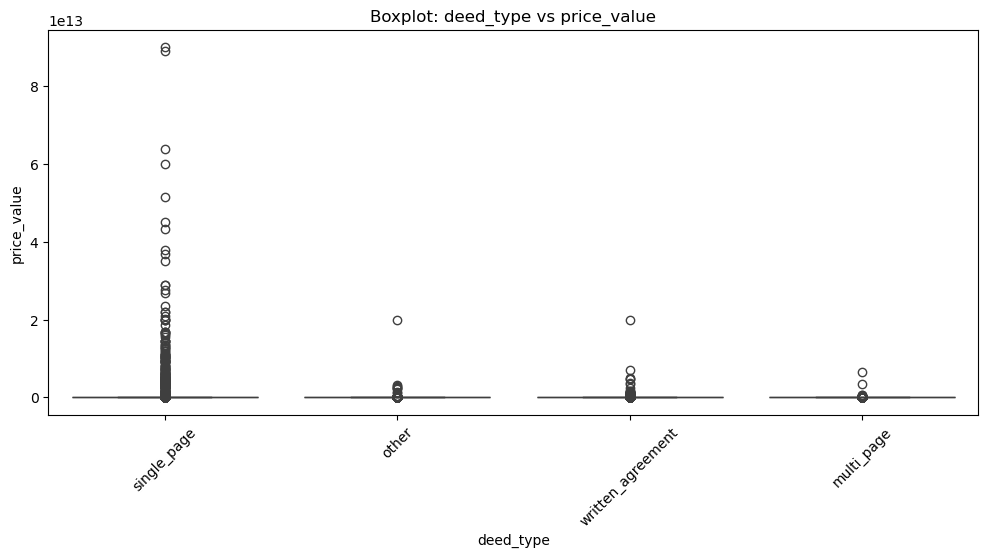

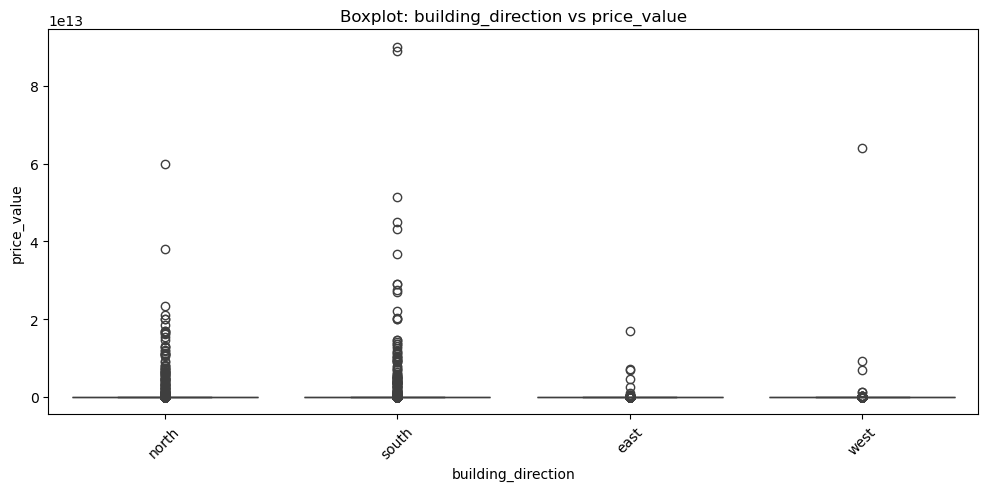

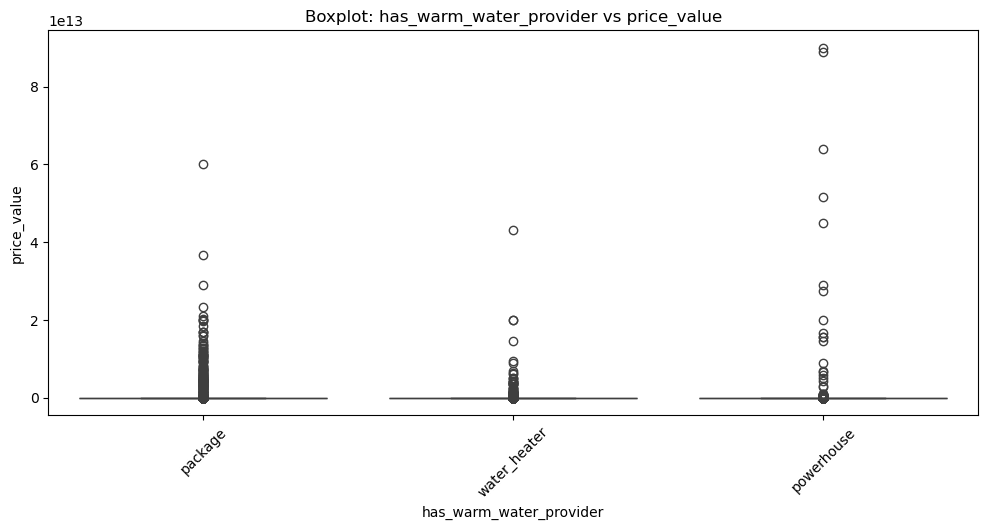

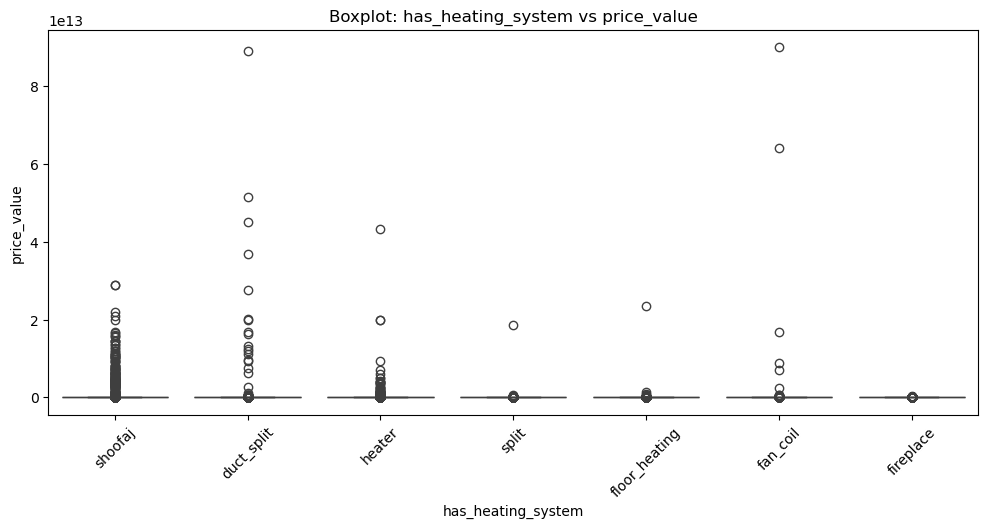

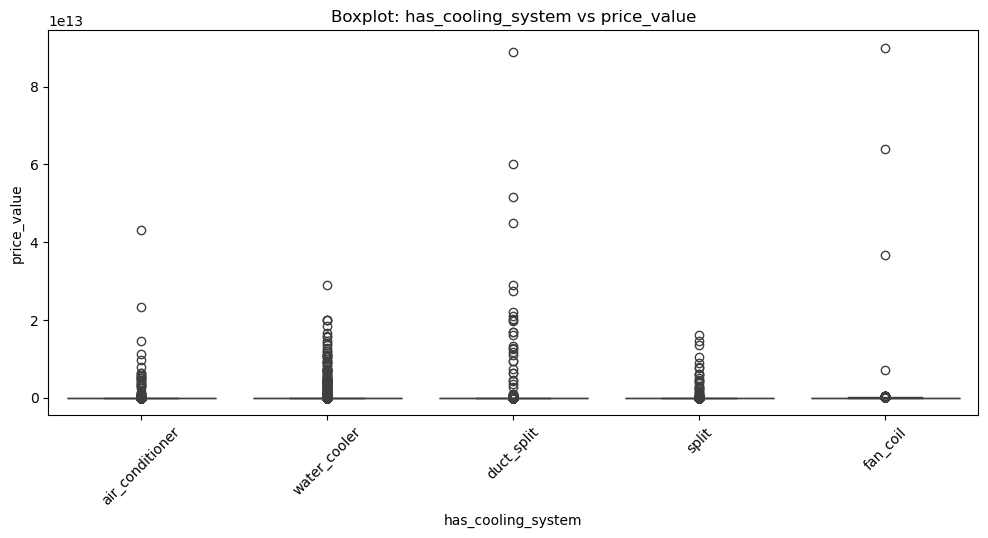

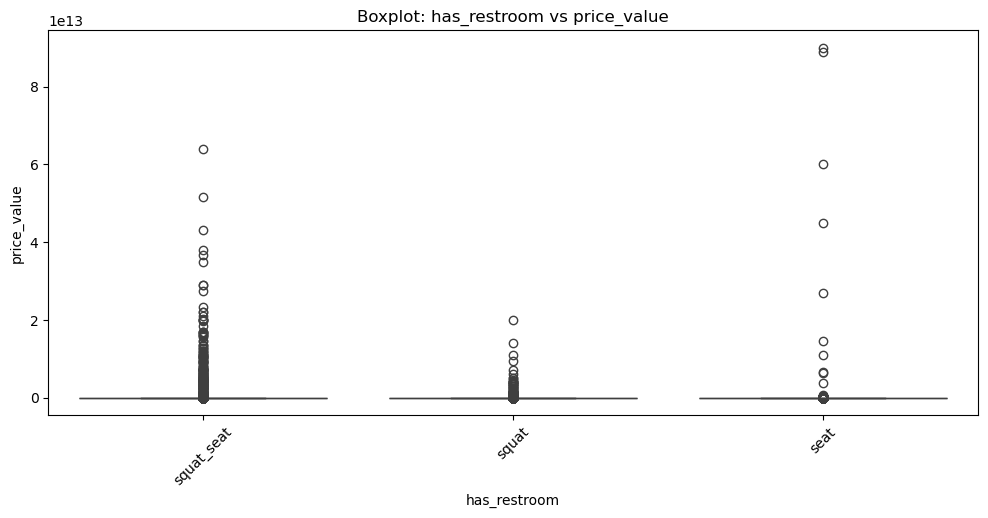

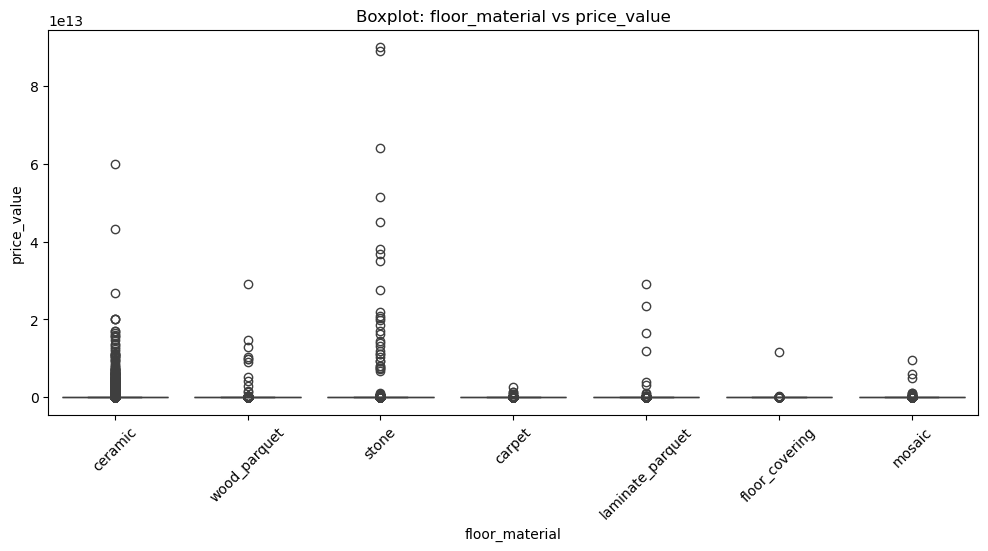

In [42]:

# -----------------------------
# ستون هدف
target_col = 'price_value'

# 1️⃣ تشخیص ستون‌های عددی و دسته‌ای
numeric_cols = ds.select_dtypes(include=['int64', 'float64', 'float32', 'Int64', 'int32']).columns.tolist()

categorical_cols = ds.select_dtypes(include=['object', 'category']).columns.tolist()

# دقت کن: numeric_cols شامل target_col هم هست
# numeric_cols = [col for col in numeric_cols if col != target_col]  # ❌ کامنت کنیم

# 2️⃣ محاسبه همبستگی ستون‌های عددی با target
corr_with_target = df_sell[numeric_cols].corr()[target_col]

# 3️⃣ انتخاب 10 ستون با بیشترین همبستگی (قدر مطلق)
top_numeric_cols = corr_with_target.abs().sort_values(ascending=False).head(15).index.tolist()

print("Top 15 numeric columns correlated with price_value:")
print(top_numeric_cols)

# 4️⃣ رسم scatterplot برای ستون‌های عددی
for col in top_numeric_cols:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=col, y=target_col, data=df_sell, alpha=0.5)
    plt.title(f'Scatter plot: {col} vs {target_col}')
    plt.show()

# 5️⃣ رسم boxplot برای ستون‌های دسته‌ای مهم
important_categorical_cols = ['cat2_slug', 'cat3_slug', 'neighborhood_slug','price_mode','deed_type','building_direction',
                              'has_warm_water_provider','has_heating_system','has_cooling_system','has_restroom','floor_material']

for col in important_categorical_cols:
    if col in df_sell.columns:
        plt.figure(figsize=(12,5))
        sns.boxplot(x=col, y=target_col, data=df_sell)
        plt.xticks(rotation=45)
        plt.title(f'Boxplot: {col} vs {target_col}')
        plt.show()


In [145]:
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import matplotlib.pyplot as plt

pdf = PdfPages("sell_plots2.pdf")   # output file

target_col = 'price_value'

numeric_cols = df_sell.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != target_col]

df_corr = df_sell[[target_col] + numeric_cols].corr()
corr_with_target = df_corr[target_col].drop(labels=[target_col])
top_numeric_cols = corr_with_target.abs().sort_values(ascending=False).head(15).index.tolist()

# Scatter plots
for col in top_numeric_cols:
    fig = plt.figure(figsize=(8,5))
    sns.scatterplot(x=col, y=target_col, data=df_sell, alpha=0.5)
    plt.title(f'{col} vs {target_col}')
    pdf.savefig(fig)  # save the figure
    plt.close(fig)

# Boxplots
important_categorical_cols = [
    'cat2_slug', 'cat3_slug', 'neighborhood_slug', 'price_mode',
    'deed_type', 'building_direction', 'has_warm_water_provider',
    'has_heating_system', 'has_cooling_system', 'has_restroom', 'floor_material'
]

for col in important_categorical_cols:
    if col in df_sell.columns:
        if df_sell[col].nunique() < 30:
            fig = plt.figure(figsize=(14,5))
            sns.boxplot(x=col, y=target_col, data=df_sell)
            plt.xticks(rotation=45)
            plt.title(f'{col} vs {target_col}')
            pdf.savefig(fig)
            plt.close(fig)

pdf.close()
print("PDF successfully saved!")


PDF successfully saved!


<Figure size 800x500 with 0 Axes>

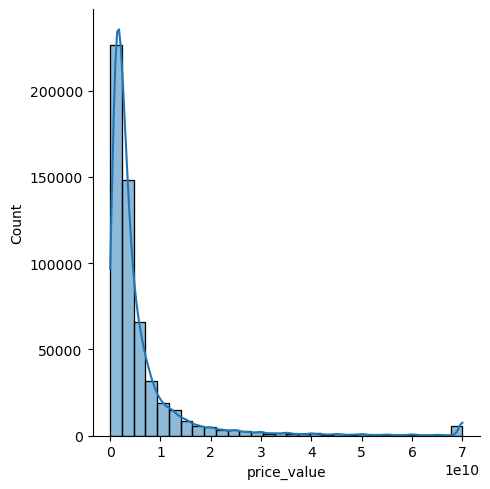

In [146]:
plt.figure(figsize=(8,5))
sns.displot(df_sell['price_value'] , bins=30 , kde=True )

In [201]:
df_sell.groupby('city_slug')['price_value'].mean().sort_values(ascending=False)

city_slug
maku             239,871,064,676
maraveh-tapeh    226,200,000,000
eqbaliyeh        111,986,579,079
jahrom           104,693,391,638
lavasan-city      96,047,279,739
                       ...      
faragi               943,200,000
khalil-shahr         928,150,085
zahak                739,318,199
sijval               491,666,667
qasemabad-khaf       377,750,188
Name: price_value, Length: 419, dtype: float64

In [189]:
df_sell.groupby(['city_slug','neighborhood_slug'])['price_value'].mean().sort_values(ascending=False).reset_index()

,city_slug,neighborhood_slug,price_value
0,tehran,jamaran,"1,936,395,426,829"
1,tehran,hezarsang,"1,769,860,555,556"
2,shiraz,shahrak-bahonar,"1,076,721,714,286"
3,tehran,darband,"496,131,457,159"
4,tehran,aghdasieh,"407,923,079,152"
...,...,...,...
1170,rasht,kuy-qods,"1,120,000,000"
1171,mashhad,arvand,"1,119,392,941"
1172,mashhad,mahdiabad,"1,089,174,618"
1173,rasht,shahrak-sanaati,"720,000,000"


# predict price of apartment and house-villa separately

In [123]:
ds=df_sell[['cat2_slug','cat3_slug','title','description','user_type','city_slug','neighborhood_slug','building_size','age',
            'price_value','has_parking','has_balcony','has_elevator','has_warehouse','floor','rooms_count','total_floors_count'
            ,'has_heating_system','has_cooling_system','has_warm_water_provider', 'has_restroom'
            ,'location_latitude','location_longitude'
           ]]


ds=ds[ds['cat3_slug']=='apartment-sell']

#ds['user_type'] = ds['user_type'].astype(str).fillna('Unknown')
ds = ds.dropna(thresh=23)
bools=['has_parking','has_balcony','has_elevator','has_warehouse']
for col in bools:
    ds[col] = ds[col].fillna(False)
    ds[col] = ds[col].astype(int)

    cat_cols = ['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug','user_type'
            ,'has_heating_system','has_warm_water_provider','has_cooling_system', 'has_restroom'
               ]
for col in cat_cols:
    
    ds[col] = ds[col].astype(str).fillna('Unknown')
    
print(ds.shape)
ds.dropna(inplace=True)
print(ds.shape)

(43222, 23)
(43222, 23)


In [124]:
#df.city_slug=df.city_slug.apply(lambda x: x.strip())
ddc=ds.copy()
city_stats=ddc.groupby('city_slug')['city_slug'].agg('count').sort_values(ascending=False)
print(len(city_stats[city_stats<=43179]))
print(len(city_stats))
city_stats_less_than_250=city_stats[city_stats<=43179]
ddc.city_slug=ddc['city_slug'].apply(lambda x: "other" if x in city_stats_less_than_250 else x)
#df.city_slug=df.city_slug.apply(lambda x: x.strip())
#dd=ds.copy()
neighborhood_stats=ds.groupby('neighborhood_slug')['neighborhood_slug'].agg('count').sort_values(ascending=False)
print(len(neighborhood_stats[neighborhood_stats<=140]))
print(len(neighborhood_stats))
neighborhood_stats_less_than_150=neighborhood_stats[neighborhood_stats<=140]
ds.neighborhood_slug=ds['neighborhood_slug'].apply(lambda x: "other" if x in neighborhood_stats_less_than_150 else x)


ds.to_csv(DATA_PROCESSED / 'df_apartment_sell.csv', index=False)

11
11
864
940


In [122]:
df_sell.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'price_mode',
       'price_value', 'land_size', 'building_size', 'deed_type', 'floor',
       'rooms_count', 'total_floors_count', 'unit_per_floor', 'has_balcony',
       'has_elevator', 'has_warehouse', 'has_parking', 'age', 'is_rebuilt',
       'has_warm_water_provider', 'necessary_facility', 'extra_facility',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'building_direction', 'floor_material', 'location_latitude',
       'location_longitude'],
      dtype='object')

In [125]:
dsh=df_sell[['cat2_slug','cat3_slug','title','description','user_type','city_slug','neighborhood_slug','age',
             'building_size','land_size','price_value','rooms_count'
            ,'has_parking','has_balcony','has_elevator','has_warehouse'
            ,'has_heating_system','has_cooling_system','has_warm_water_provider', 'has_restroom'
             ,'location_latitude','location_longitude'
           ]]
dsh=dsh[(dsh['cat3_slug']=='house-villa-sell')|(dsh['cat3_slug']=='plot-old')]
#dsh['user_type'] = dsh['user_type'].astype(str).fillna('Unknown')
dsh = dsh.dropna(thresh=20)
bools=['has_parking','has_balcony','has_elevator','has_warehouse']
for col in bools:
    dsh[col] = dsh[col].fillna(False)
    dsh[col] = dsh[col].astype(int)

cat_cols = ['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug','user_type'
            ,'has_heating_system','has_warm_water_provider','has_cooling_system'
               ]
for col in cat_cols:    
    dsh[col] = dsh[col].astype(str).fillna('Unknown')

print(dsh.shape)
dsh.dropna(inplace=True)
print(dsh.shape)


(13700, 22)
(13671, 22)


In [126]:
#df.city_slug=df.city_slug.apply(lambda x: x.strip())
#dd=dsh.copy()
city_stats=dsh.groupby('city_slug')['city_slug'].agg('count').sort_values(ascending=False)
print(len(city_stats[city_stats<=30]))
print(len(city_stats))
city_stats_less_than_250=city_stats[city_stats<=30]
dsh.city_slug=dsh['city_slug'].apply(lambda x: "other" if x in city_stats_less_than_250 else x)
#df.city_slug=df.city_slug.apply(lambda x: x.strip())
#dd=dsh.copy()
neighborhood_stats=dsh.groupby('neighborhood_slug')['neighborhood_slug'].agg('count').sort_values(ascending=False)
print(len(neighborhood_stats[neighborhood_stats<=18]))
print(len(neighborhood_stats))
neighborhood_stats_less_than_40=neighborhood_stats[neighborhood_stats<=18]
dsh.neighborhood_slug=dsh['neighborhood_slug'].apply(lambda x: "other" if x in neighborhood_stats_less_than_40 else x)

dsh.to_csv(DATA_PROCESSED / 'df_house_sell.csv', index=False)

248
308
834
914


Final transformed shape: (21030, 269)
Training LinearRegression ...
LinearRegression
  r2: 0.4473
  MAE: 3388681220.4538
  RMSE: 5477711607.6678
----------------------------------------
Training Ridge ...
Ridge
  r2: 0.4477
  MAE: 3388406974.0587
  RMSE: 5475989631.1872
----------------------------------------
Training RandomForest ...
RandomForest
  r2: 0.6744
  MAE: 2275637424.3169
  RMSE: 4204449988.7970
----------------------------------------
Training KNN ...
KNN
  r2: 0.4542
  MAE: 3073026060.7680
  RMSE: 5443698572.3743
----------------------------------------
Training CatBoost ...
CatBoost
  r2: 0.6753
  MAE: 2320301008.1885
  RMSE: 4198727350.6898
----------------------------------------
Best model by MAE: RandomForest
num__building_size                          0
num__land_size                              0
num__location_latitude                      0
num__location_longitude                     0
num__age                                    0
cat__city_slug_tehran           

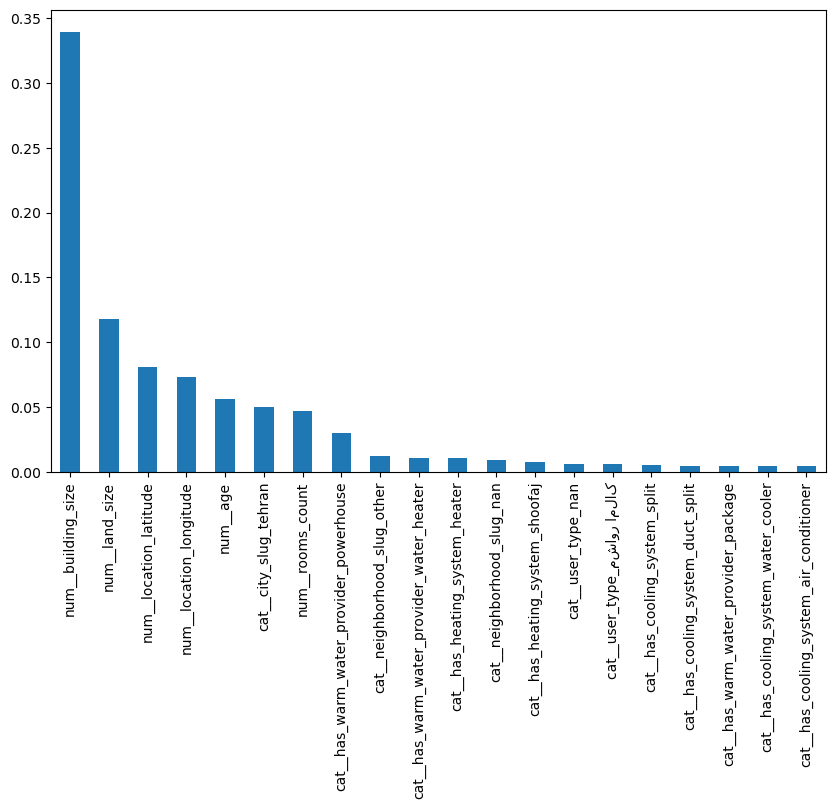

Pipeline finished. Models ready, predictions added to df_model.


In [152]:
# predict house-villa-sell and plot-old use dsh

# ===== helper functions =====
def regression_report(y_true, y_pred):
    return {
        "r2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

def show_scores(name, scores_dict):
    print(name)
    for k, v in scores_dict.items():
        print(f"  {k}: {v:.4f}")
    print('-'*40)

# ===== DATA PREP =====
df_model = dsh.copy()
df_model = df_model[df_model['price_value'].notna()].reset_index(drop=True)

# Select features
candidate_features = [
    'building_size','land_size','rooms_count','age','user_type','has_parking','has_balcony','has_elevator','has_warehouse',
    'city_slug','cat3_slug','neighborhood_slug','has_heating_system','has_cooling_system','has_warm_water_provider', 'has_restroom'
     ,'location_latitude','location_longitude'
]
candidate_features = [c for c in candidate_features if c in df_model.columns]

X = df_model[candidate_features]
y = df_model['price_value']

# Numeric & Categorical features
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# ===== Preprocessor =====
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ],
    remainder='drop'
)

# ===== Split =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===== Fit & Transform =====
preprocessor.fit(X_train)
X_train_p = preprocessor.transform(X_train)
X_test_p = preprocessor.transform(X_test)

# ===== Convert to Dense & DataFrame =====
def make_dataframe(transformed, index):
    # convert from sparse if needed
    if sparse.issparse(transformed):
        transformed = transformed.toarray()

    feature_names = preprocessor.get_feature_names_out()
    return pd.DataFrame(transformed, columns=feature_names, index=index)

X_train_p = make_dataframe(X_train_p, X_train.index)
X_test_p = make_dataframe(X_test_p, X_test.index)

print("Final transformed shape:", X_train_p.shape)

# ===== Train Models =====
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN': KNeighborsRegressor(n_neighbors=8),
    'CatBoost': CatBoostRegressor(iterations=500, verbose=0, random_state=42)
}

results = {}
for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train_p, y_train)
    preds = model.predict(X_test_p)
    scores = regression_report(y_test, preds)
    results[name] = scores
    show_scores(name, scores)

# ===== Best Model =====
best_model_name = min(results.keys(), key=lambda k: results[k]['MAE'])
print("Best model by MAE:", best_model_name)
best_model = models[best_model_name]

# ===== Refit on full data =====
X_full_p = preprocessor.transform(X)
X_full_p = make_dataframe(X_full_p, X.index)

best_model.fit(X_full_p, y)
df_model['predicted_price'] = best_model.predict(X_full_p)

# ===== Price Category =====
df_model['price_ratio'] = df_model['price_value'] / (df_model['predicted_price'] + 1e-9)

def categorize_ratio(r):
    if r > 1.2:
        return 'Over-value'
    elif r < 0.9:
        return 'Under-value'
    else:
        return 'Normal'

df_model['price_category'] = df_model['price_ratio'].apply(categorize_ratio)

# ===== Feature Importance =====
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X_train_p.columns).sort_values(ascending=False)
    print(fi.head(20))
    fi.head(20).plot(kind='bar', figsize=(10,6))
    plt.show()

# ===== Save Model =====
joblib.dump(best_model, "best_price_model.joblib")
joblib.dump(preprocessor, "preprocessor.joblib")

print("Pipeline finished. Models ready, predictions added to df_model.")


Final transformed shape: (34892, 109)
Training LinearRegression ...
LinearRegression
  r2: 0.7131
  MAE: 2854915561.8106
  RMSE: 4462841285.8101
----------------------------------------
Training Ridge ...
Ridge
  r2: 0.7137
  MAE: 2858249824.9834
  RMSE: 4457540326.8371
----------------------------------------
Training RandomForest ...
RandomForest
  r2: 0.8984
  MAE: 1204659265.1142
  RMSE: 2655859395.6430
----------------------------------------
Training KNN ...
KNN
  r2: 0.7726
  MAE: 2152707526.6121
  RMSE: 3972570036.8683
----------------------------------------
Training CatBoost ...
CatBoost
  r2: 0.9080
  MAE: 1232099429.9517
  RMSE: 2527323900.8031
----------------------------------------
Best model by MAE: RandomForest
num__building_size                          1
cat__city_slug_tehran                       0
num__location_latitude                      0
num__location_longitude                     0
num__age                                    0
cat__has_heating_system_shoofaj 

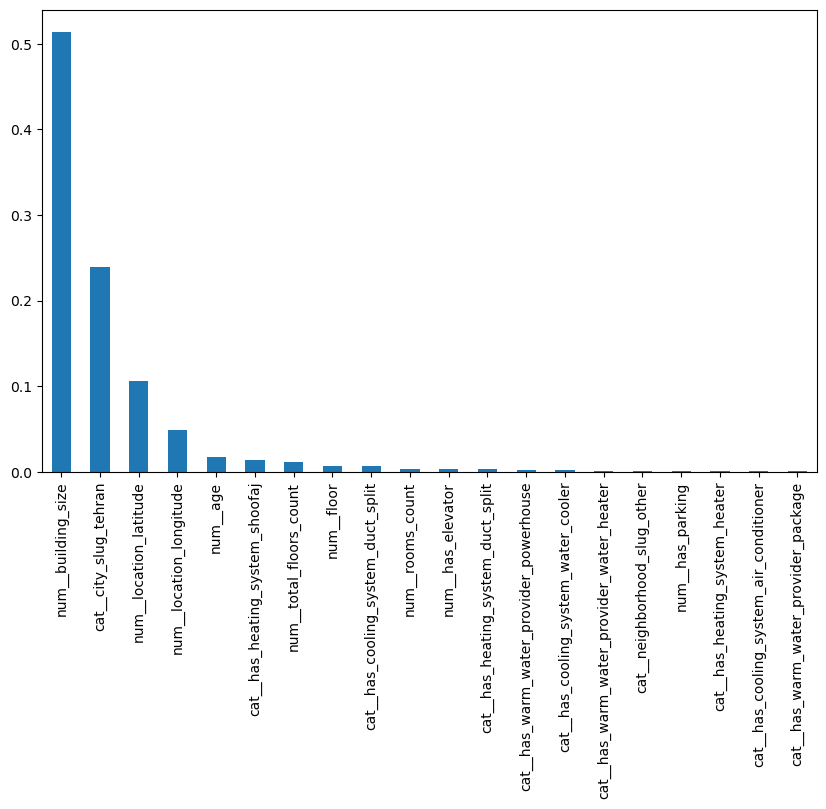

Pipeline finished. Models ready, predictions added to df_model.


In [144]:

#predict for sell apartment use ds
# ===== helper functions =====
def regression_report(y_true, y_pred):
    return {
        "r2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

def show_scores(name, scores_dict):
    print(name)
    for k, v in scores_dict.items():
        print(f"  {k}: {v:.4f}")
    print('-'*40)

# ===== DATA PREP =====
df_model = ds.copy()
df_model = df_model[df_model['price_value'].notna()].reset_index(drop=True)

# Select features
candidate_features = [
    'building_size','rooms_count','floor','total_floors_count','age','neighborhood_slug',
    'city_slug','has_parking','has_balcony','has_elevator','has_warehouse','user_type'
            ,'has_heating_system','has_cooling_system','has_warm_water_provider', 'has_restroom'
        ,'location_latitude','location_longitude'
]
candidate_features = [c for c in candidate_features if c in df_model.columns]

X = df_model[candidate_features]
y = df_model['price_value']

# Numeric & Categorical features
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# ===== Preprocessor =====
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ],
    remainder='drop'
)

# ===== Split =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===== Fit & Transform =====
preprocessor.fit(X_train)
X_train_p = preprocessor.transform(X_train)
X_test_p = preprocessor.transform(X_test)

# ===== Convert to Dense & DataFrame =====
def make_dataframe(transformed, index):
    # convert from sparse if needed
    if sparse.issparse(transformed):
        transformed = transformed.toarray()

    feature_names = preprocessor.get_feature_names_out()
    return pd.DataFrame(transformed, columns=feature_names, index=index)

X_train_p = make_dataframe(X_train_p, X_train.index)
X_test_p = make_dataframe(X_test_p, X_test.index)

print("Final transformed shape:", X_train_p.shape)

# ===== Train Models =====
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN': KNeighborsRegressor(n_neighbors=8),
    'CatBoost': CatBoostRegressor(iterations=500, verbose=0, random_state=42)
}

results = {}
for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train_p, y_train)
    preds = model.predict(X_test_p)
    scores = regression_report(y_test, preds)
    results[name] = scores
    show_scores(name, scores)

# ===== Best Model =====
best_model_name = min(results.keys(), key=lambda k: results[k]['MAE'])
print("Best model by MAE:", best_model_name)
best_model = models[best_model_name]

# ===== Refit on full data =====
X_full_p = preprocessor.transform(X)
X_full_p = make_dataframe(X_full_p, X.index)

best_model.fit(X_full_p, y)
df_model['predicted_price'] = best_model.predict(X_full_p)

# ===== Price Category =====
df_model['price_ratio'] = df_model['price_value'] / (df_model['predicted_price'] + 1e-9)

def categorize_ratio(r):
    if r > 1.2:
        return 'Over-value'
    elif r < 0.9:
        return 'Under-value'
    else:
        return 'Normal'

df_model['price_category'] = df_model['price_ratio'].apply(categorize_ratio)

# ===== Feature Importance =====
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X_train_p.columns).sort_values(ascending=False)
    print(fi.head(20))
    fi.head(20).plot(kind='bar', figsize=(10,6))
    plt.show()

# ===== Save Model =====
joblib.dump(best_model, "best_price_model.joblib")
joblib.dump(preprocessor, "preprocessor.joblib")

print("Pipeline finished. Models ready, predictions added to df_model.")


In [ ]:
#predict apartment sell using gridsearchCV

# ML utils
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# =====================================================
#  REPORT FUNCTIONS
# =====================================================
def regression_report(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

def show_scores(name, scores):
    print(name)
    for k, v in scores.items():
        print(f"  {k}: {v:.4f}")
    print("-" * 40)


# =====================================================
#  ===== DATA PREPARATION =====
# =====================================================
df_model = ds.copy()
df_model = df_model[df_model["price_value"].notna()].reset_index(drop=True)

candidate_features = [
    "building_size","rooms_count","floor","total_floors_count","age","neighborhood_slug",
    "city_slug","has_parking","has_balcony","has_elevator","has_warehouse","user_type",
    "has_heating_system","has_cooling_system","has_warm_water_provider","has_restroom",
    "location_latitude","location_longitude"
]

candidate_features = [c for c in candidate_features if c in df_model.columns]

X = df_model[candidate_features]
y = df_model["price_value"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()


# =====================================================
#  PREPROCESSOR (Scaler + OneHot)
# =====================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


# =====================================================
# TRAIN/TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =====================================================
#  MODEL 1 — Linear Regression
# =====================================================
pipe_lr = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)
scores_lr = regression_report(y_test, pred_lr)
show_scores("Linear Regression", scores_lr)


# =====================================================
#  MODEL 2 — Ridge Regression (GridSearch)
# =====================================================
ridge_params = {"model__alpha": [0.1, 1, 5, 10, 20, 50, 100]}

pipe_ridge = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge())
])

grid_ridge = GridSearchCV(pipe_ridge, ridge_params, cv=5, n_jobs=-1)
grid_ridge.fit(X_train, y_train)

pred_ridge = grid_ridge.predict(X_test)
scores_ridge = regression_report(y_test, pred_ridge)
show_scores("Ridge Regression", scores_ridge)


# =====================================================
#  MODEL 3 — KNN (GridSearch)
# =====================================================
knn_params = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"]
}

pipe_knn = Pipeline([
    ("prep", preprocessor),
    ("model", KNeighborsRegressor())
])

grid_knn = GridSearchCV(pipe_knn, knn_params, cv=5, n_jobs=-1)
grid_knn.fit(X_train, y_train)

pred_knn = grid_knn.predict(X_test)
scores_knn = regression_report(y_test, pred_knn)
show_scores("KNN", scores_knn)


# =====================================================
#  MODEL 4 — Random Forest (GridSearch)
# =====================================================
rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10]
}

pipe_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

grid_rf = GridSearchCV(pipe_rf, rf_params, cv=5, n_jobs=-1)
grid_rf.fit(X_train, y_train)

pred_rf = grid_rf.predict(X_test)
scores_rf = regression_report(y_test, pred_rf)
show_scores("Random Forest", scores_rf)


Linear Regression
  R2: 0.7173
  MAE: 1493595189.6917
  RMSE: 1989356836.8182
----------------------------------------
Ridge Regression
  R2: 0.7170
  MAE: 1494855782.0773
  RMSE: 1990413284.2179
----------------------------------------
KNN
  R2: 0.7760
  MAE: 1140194790.4664
  RMSE: 1770829889.9027
----------------------------------------
